## 1. Data preprocessing

In [10]:
import pandas as pd

data_path = "../data/GiveMeCredit/"
df = pd.read_csv(data_path + "cs-training.csv", index_col=0)
df.reset_index(drop=True, inplace=True)


In [11]:
# # NOTEARS and ReX require numeric, complete matrices, so missing data must be resolved.
# df = df.fillna(df.median())

print(df.shape)
df = df.dropna()
df.head()

print(df.shape)

(150000, 11)
(120269, 11)


In [12]:
# Only supports numeric input. Categorical features must be encoded numerically.
df.dtypes

SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime3059DaysPastDueNotWorse       int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime6089DaysPastDueNotWorse       int64
NumberOfDependents                      float64
dtype: object

In [13]:
pd.value_counts(df['SeriousDlqin2yrs'])

/var/folders/4x/nynq10qj2kz8_zbvh7mnk0y00000gn/T/ipykernel_36658/1250700869.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df['SeriousDlqin2yrs'])


SeriousDlqin2yrs
0    111912
1      8357
Name: count, dtype: int64

In [14]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime3059DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime6089DaysPastDueNotWorse,NumberOfDependents
count,120269.000000,120269.000000,120269.000000,120269.000000,120269.000000,1.202690e+05,120269.000000,120269.000000,120269.000000,120269.000000,120269.000000
mean,0.069486,5.899873,51.289792,0.381769,26.598777,6.670221e+03,8.758475,0.211925,1.054519,0.187829,0.851832
std,0.254280,257.040685,14.426684,3.499234,424.446457,1.438467e+04,5.172835,3.465276,1.149273,3.447901,1.148391
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.035084,40.000000,0.000000,0.143388,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.177282,51.000000,0.000000,0.296023,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.579428,61.000000,0.000000,0.482559,8.249000e+03,11.000000,0.000000,2.000000,0.000000,2.000000
max,1.000000,50708.000000,103.000000,98.000000,61106.500000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [15]:
# # Continuous numeric features should be scaled. Recommended for NOTEARS (sensitive to magnitude)

# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# df_scaled = pd.DataFrame(
#     scaler.fit_transform(df),
#     columns=df.columns
# )

# df_scaled.head()

In [18]:
"""
Preprocessing pipeline for Give Me Some Credit dataset
Causal discovery–ready (NOTEARS / ReX)
"""

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, QuantileTransformer, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


class CreditDataPreprocessor:
    def __init__(self, path, test_size=0.2, random_state=42, subsample_ratio = 1):
        self.path = path
        self.test_size = test_size
        self.random_state = random_state

        # subsample_ratio:
        # 1.0  -> balanced (1:1)
        # 2.0  -> twice as many majority samples as minority
        # None -> no subsampling (use full dataset)
        self.subsample_ratio = subsample_ratio
        self.target = "SeriousDlqin2yrs"
        
        self.log_vars = [
            "NumberOfTime3059DaysPastDueNotWorse",
            "NumberOfTime6089DaysPastDueNotWorse",
            "NumberOfTimes90DaysLate",
            "NumberOfOpenCreditLinesAndLoans",
            "NumberRealEstateLoansOrLines",
            "NumberOfDependents" # NOTE: add context variables 
        ]

        self.quantile_vars = [
            "RevolvingUtilizationOfUnsecuredLines",
            "DebtRatio",
        ]

        self.standard_vars = [
            "MonthlyIncome",
            "age" # NOTE: add context variables 
        ]

        self.context_vars = ["age", "NumberOfDependents"]

        self._build_pipeline()

    def _build_pipeline(self):
        self.pipeline = ColumnTransformer(
            transformers=[
                (
                    "log",
                    Pipeline([
                        ("impute", SimpleImputer(strategy="constant", fill_value=0)),
                        ("log", FunctionTransformer(np.log1p)),
                        ("scale", StandardScaler()),
                    ]),
                    self.log_vars,
                ),
                (
                    "quantile",
                    Pipeline([
                        ("impute", SimpleImputer(strategy="constant", fill_value=0)),
                        ("quant", QuantileTransformer(output_distribution="normal")),
                    ]),
                    self.quantile_vars,
                ),
                (
                    "standard",
                    Pipeline([
                        ("impute", SimpleImputer(strategy="median")),
                        ("scale", StandardScaler()),
                    ]),
                    self.standard_vars,
                ),
            ],
            remainder="drop",
        )

    def load_and_process(self):
        df = pd.read_csv(self.path, index_col=0)

        # Basic cleaning
        df = df.reset_index(drop=True)
        df = df.dropna()
        # Age filter to removes elderly outliers
        df = df[df["age"] < 88]

        # Separate target, features, context variables
        y = df[self.target].astype(int).values
        # NOTE: add [context variables] into quantile_vars and standard_vars
        X = df[self.log_vars + self.quantile_vars + self.standard_vars] 
        context = df[self.context_vars].copy()

        # NOTE-update: Subsampling (optional, to balance classes)
        if self.subsample_ratio is not None:
            rng = np.random.default_rng(self.random_state)
        
            idx_major = np.where(y == 0)[0]
            idx_minor = np.where(y == 1)[0]
        
            n_major = min(int(len(idx_minor) * self.subsample_ratio), len(idx_major))
            idx_major_sub = rng.choice(idx_major, size=n_major, replace=False)
        
            idx_sub = np.concatenate([idx_minor, idx_major_sub])
            idx_sub = rng.permutation(idx_sub)
        
            X = X.iloc[idx_sub].reset_index(drop=True)
            y = y[idx_sub]
            context = context.iloc[idx_sub].reset_index(drop=True) 
        
        # Binary context (optional, for analysis)
        context["ageAbove50"] = (context["age"] > 50).astype(int)
        context["HasDependents"] = (context["NumberOfDependents"] > 0).astype(int)
        context = context[["ageAbove50", "HasDependents"]]

        # Train-test split
        X_train, X_test, y_train, y_test, c_train, c_test = train_test_split(
            X, y, context,
            test_size=self.test_size,
            random_state=self.random_state,
            stratify=y,
        )

        # Fit + transform
        X_train = self.pipeline.fit_transform(X_train)
        X_test = self.pipeline.transform(X_test)
        
        # NOTE: add context variables into quantile_vars and standard_vars
        self.feature_names_ = (self.log_vars + self.quantile_vars + self.standard_vars)  

        # TODO: add function revert the normalized varibles back
        
        return {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
            "context_train": c_train.values,
            "context_test": c_test.values,
            "feature_names": self.feature_names_,
        }


In [20]:
data = CreditDataPreprocessor(data_path + "cs-training.csv")
data_processed = data.load_and_process()

print("X_train shape:", data_processed["X_train"].shape)
print("Positive class rate:", data_processed["y_train"].mean())

X_train shape: (13334, 10)
Positive class rate: 0.5


In [ ]:
train_processed = pd.DataFrame(data_processed['X_train'], columns=data_processed['feature_names'])

train_processed.to_csv("./data_processed/credit_processed__downsampled.csv", index=False)

## 2. Causal discovery models

In [ ]:
from causalexplain import GraphDiscovery

# Create experiment object
gd = GraphDiscovery(
    experiment_name="credit_causal",
    model_type="rex",               
    csv_filename="./data_processed/credit_processed_downsampled.csv", # your dataset
)

### 2.1 With no prior constraints

In [24]:
# Run causal discovery
gd.run(
    hpo_iterations=5, 
    # hpo_iterations=0, 
    bootstrap_iterations=30, 
    combine_op="union", 
    model_params={"hpo_min_loss": -1e9} # force min_loss to a number that will never be reached
)


Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

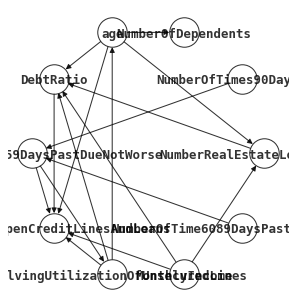

In [25]:
# Plot or inspect the learned graph
gd.plot(show_metrics=True, layout='circular', usetex=False)


In [26]:
# Save the learned model & export DOT format
gd.export("credit_rex3_no_constraints.dot")

### 2.2 With 4-tier prior constraints

In [27]:
# Recommended tier structure (5 tiers)
# Tier 0 — Demographics (root causes)
# age
# NumberOfDependents

# Tier 1 — Income (capacity)
# MonthlyIncome

# Tier 2 — Financial structure (leverage & assets)
# DebtRatio
# NumberRealEstateLoansOrLines


# Tier 3 — Credit access & utilization
# RevolvingUtilizationOfUnsecuredLines
# NumberOfOpenCreditLinesAndLoans

# Tier 4 — Payment behavior (delinquency signals)
# NumberOfTimes90DaysLate
# NumberOfTime6089DaysPastDueNotWorse
# NumberOfTime3059DaysPastDueNotWorse

prior = [
    ["age", "NumberOfDependents"],
    ["MonthlyIncome"],
    ["DebtRatio", "NumberRealEstateLoansOrLines"],
    ["RevolvingUtilizationOfUnsecuredLines", "NumberOfOpenCreditLinesAndLoans"],
    [
      "NumberOfTimes90DaysLate",
      "NumberOfTime6089DaysPastDueNotWorse",
      "NumberOfTime3059DaysPastDueNotWorse"
    ]
  ]


In [28]:
# NOTE: run with constraints: prior

# Run causal discovery
gd.run(
    hpo_iterations=5, 
    # hpo_iterations=0, 
    bootstrap_iterations=30, 
    combine_op="union", 
    prior=prior,
    model_params={"hpo_min_loss": -1e9} # force min_loss to a number that will never be reached
)



Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

In [29]:
# Numbers of trainer from REX
print(gd.trainer)
print()

# SHAP sampling summary
print(gd._sampling_summary())

{'credit_processed_subsample_nn': <causalexplain.common.notebook.Experiment object at 0x3598af140>, 'credit_processed_subsample_gbt': <causalexplain.common.notebook.Experiment object at 0x34bcfa3c0>, 'credit_processed_subsample_rex': <causalexplain.common.notebook.Experiment object at 0x359ab7800>}

SHAP adaptive sampling: multi_sample (K=5, samples=512)


In [30]:
import networkx as nx

print(gd.dag.number_of_nodes())
print(gd.dag.number_of_edges())

10
1


In [31]:
# Adjacency matrix
import pandas as pd

adj_df = pd.DataFrame(
    nx.to_numpy_array(gd.dag, nodelist=gd.data_columns),
    index=gd.data_columns,
    columns=gd.data_columns
)

adj_df

,NumberOfTime3059DaysPastDueNotWorse,NumberOfTime6089DaysPastDueNotWorse,NumberOfTimes90DaysLate,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,RevolvingUtilizationOfUnsecuredLines,DebtRatio,MonthlyIncome,age
NumberOfTime3059DaysPastDueNotWorse,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
NumberOfTime6089DaysPastDueNotWorse,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
NumberOfTimes90DaysLate,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
NumberOfOpenCreditLinesAndLoans,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
NumberRealEstateLoansOrLines,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
NumberOfDependents,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
RevolvingUtilizationOfUnsecuredLines,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
DebtRatio,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
MonthlyIncome,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
age,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


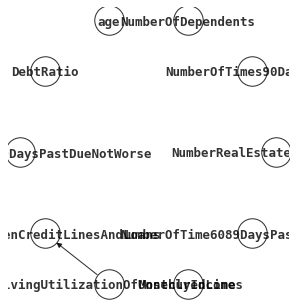

In [32]:
# Plot or inspect the learned graph
gd.plot(show_metrics=True, layout='circular', usetex=False)


In [41]:
# gd.plot(figsize=(10, 8), dpi=300, layout='circular', usetex=False)


In [33]:
# Save the learned model & export DOT format
gd.export("credit_rex4_constraints.dot")

### 2.3 With minimal prior constraints

In [36]:
prior_minimal = [
    ["age", "NumberOfDependents"],
    [
      "MonthlyIncome",
      "DebtRatio",
      "NumberRealEstateLoansOrLines",
      "NumberOfOpenCreditLinesAndLoans",
      "RevolvingUtilizationOfUnsecuredLines",
      "NumberOfTimes90DaysLate",
      "NumberOfTime3059DaysPastDueNotWorse",
      "NumberOfTime6089DaysPastDueNotWorse"
    ]
]

In [37]:
# NOTE: run with constraints: prior_minimal

# Run causal discovery
gd.run(
    hpo_iterations=5, 
    # hpo_iterations=0, 
    bootstrap_iterations=30, 
    combine_op="union", 
    prior=prior_minimal,
    model_params={"hpo_min_loss": -1e9} # force min_loss to a number that will never be reached
)


Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

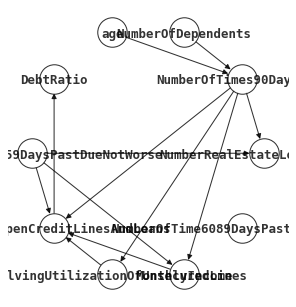

In [38]:
# Plot or inspect the learned graph
gd.plot(show_metrics=True, layout='circular', usetex=False)


In [39]:
# gd.plot(figsize=(10, 8), dpi=300, layout='circular', usetex=False)


In [40]:
# Save the learned model & export DOT format
gd.export("credit_rex5_constraints_min.dot")

### 2.4 With moderate prior constraints

In [41]:
prior_mod = [
    ["age", "NumberOfDependents"],
    [
    "MonthlyIncome",
    "DebtRatio",
    "NumberRealEstateLoansOrLines",
    "NumberOfOpenCreditLinesAndLoans",
    "RevolvingUtilizationOfUnsecuredLines",
    ],
    [ 
    "NumberOfTimes90DaysLate",
    "NumberOfTime3059DaysPastDueNotWorse",
    "NumberOfTime6089DaysPastDueNotWorse"
    ]
  ]

In [42]:
# NOTE: run with constraints: prior_minimal

# Run causal discovery
gd.run(
    hpo_iterations=5, 
    # hpo_iterations=0, 
    bootstrap_iterations=30, 
    combine_op="union", 
    prior=prior_mod,
    model_params={"hpo_min_loss": -1e9} # force min_loss to a number that will never be reached
)


Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

Output()

Output()

Setting tolerance to 0.3, as no true_graph was provided.

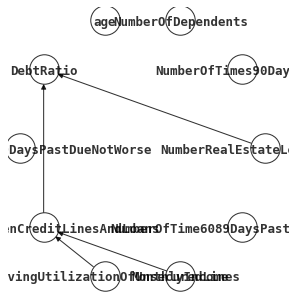

In [43]:
# Plot or inspect the learned graph
gd.plot(show_metrics=True, layout='circular', usetex=False)


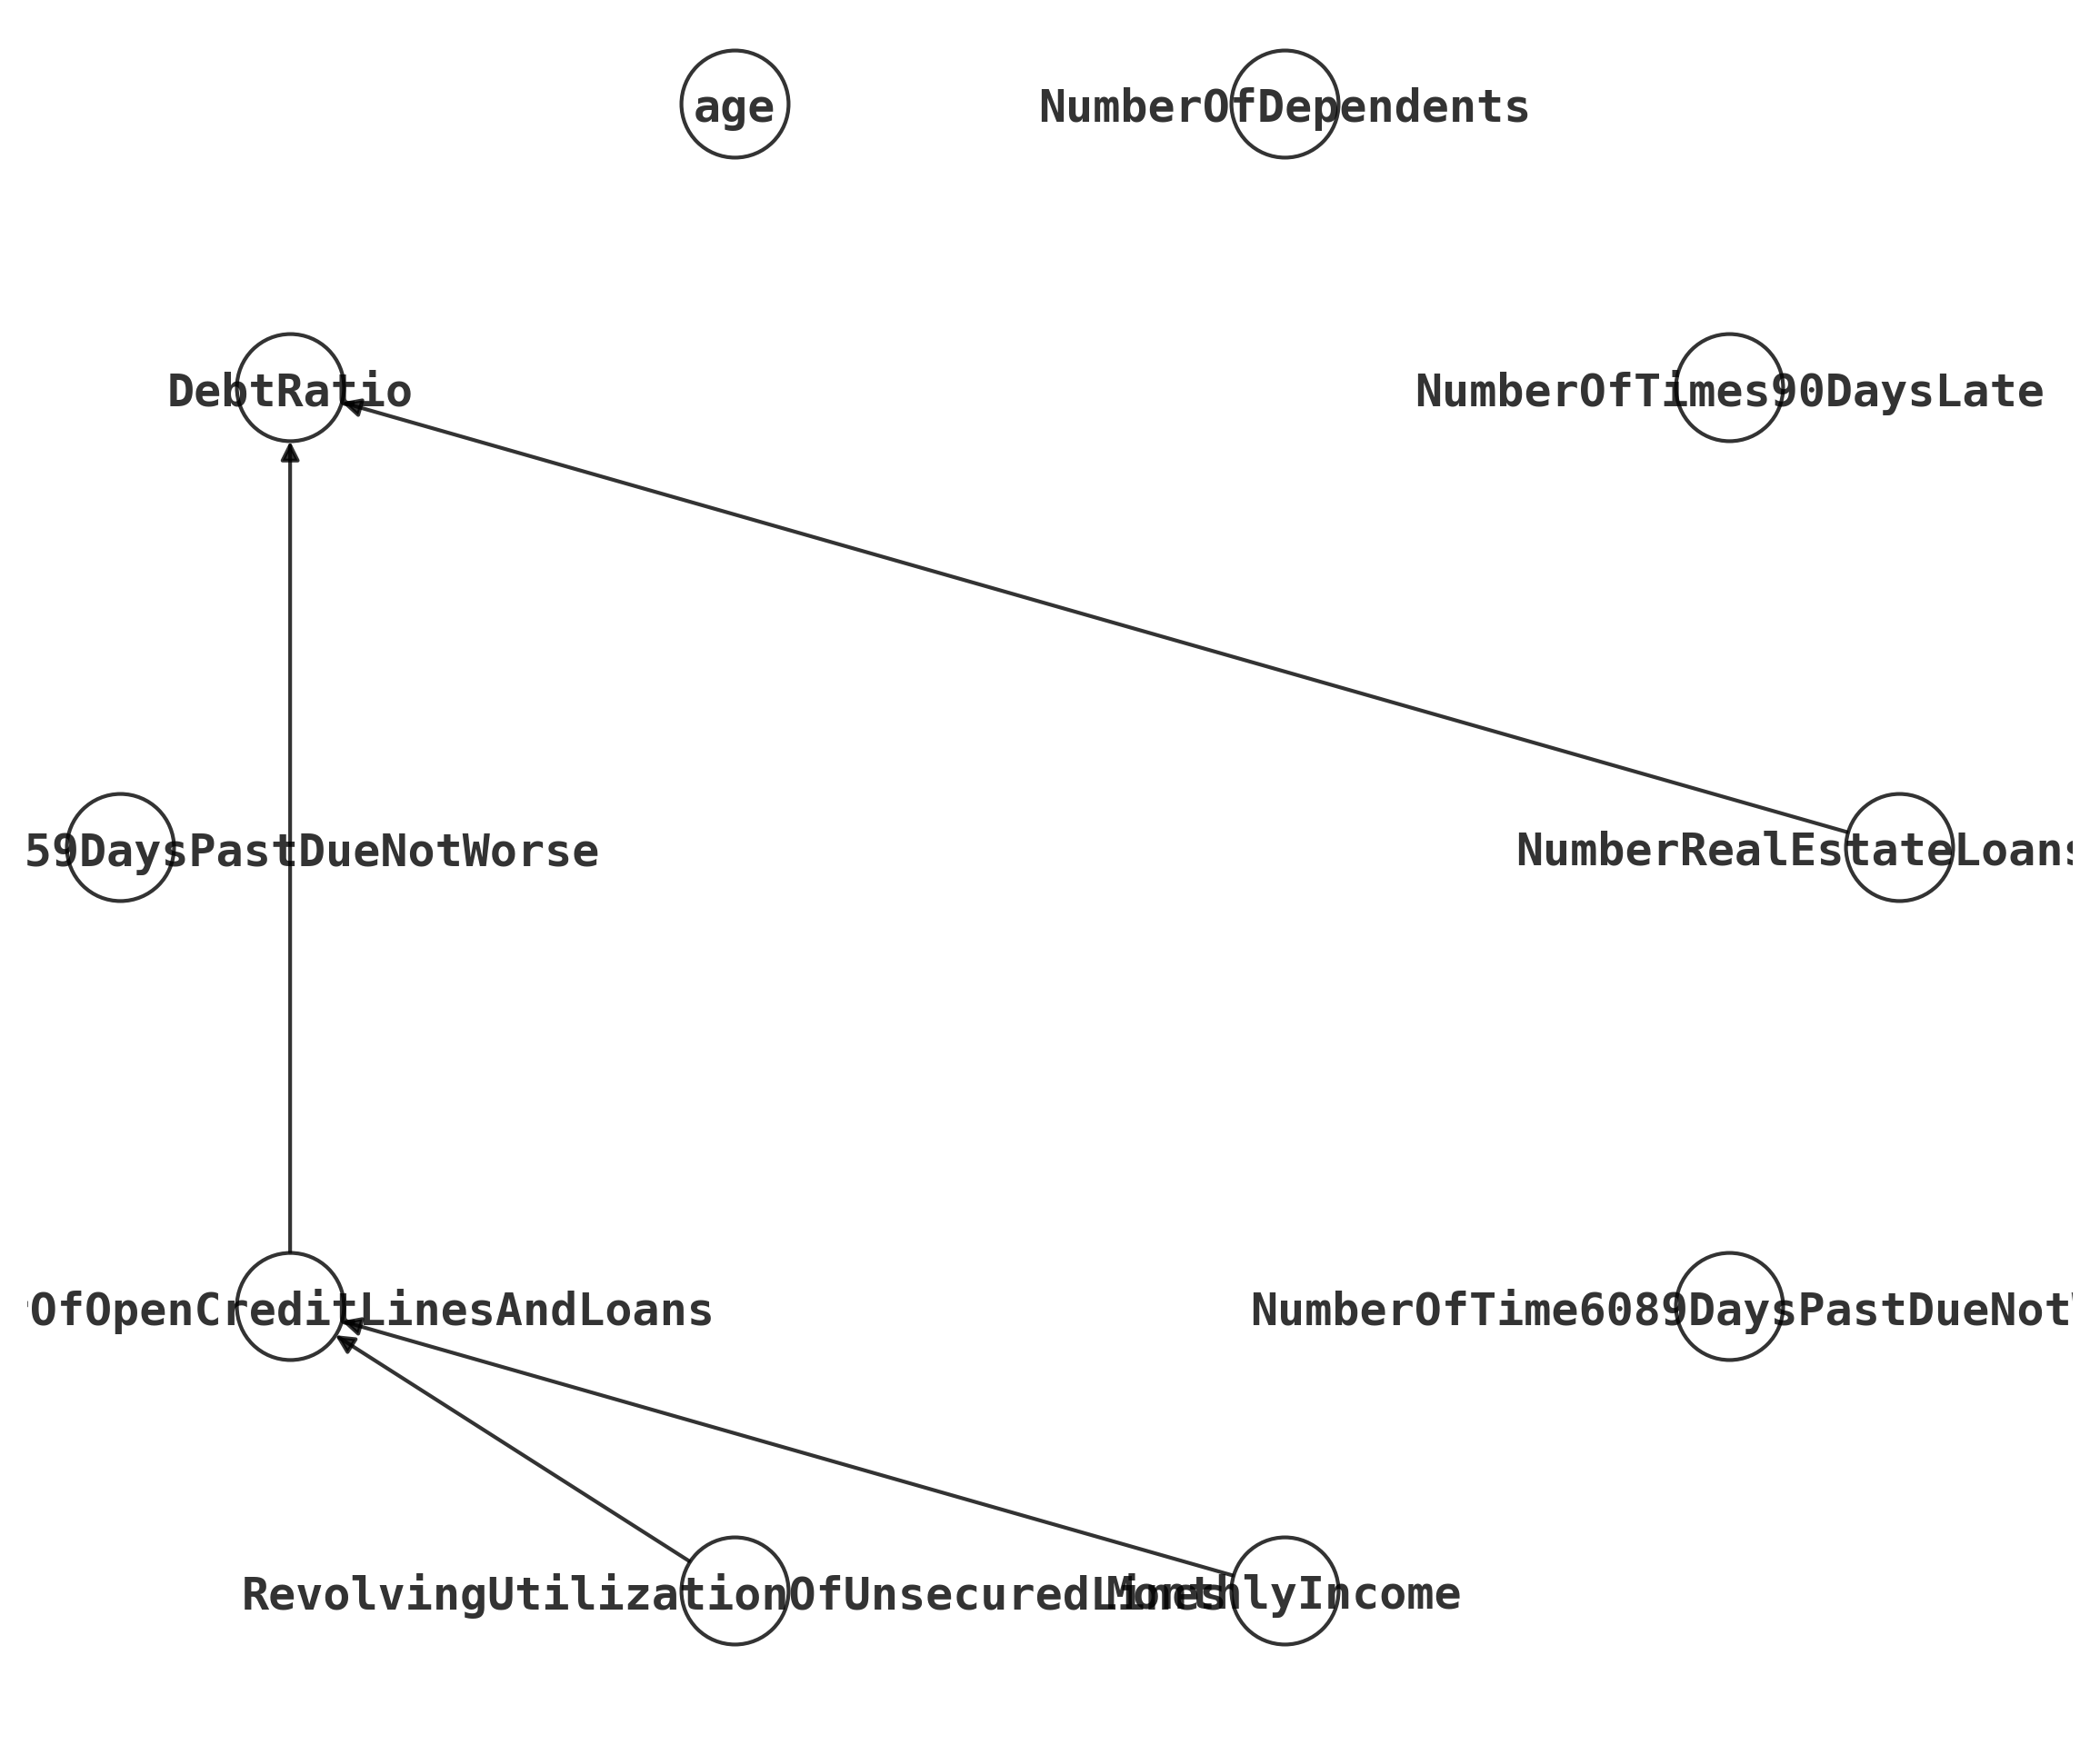

In [45]:
gd.plot(figsize=(10, 8), dpi=300, layout='circular', usetex=False)


In [44]:
# Save the learned model & export DOT format
gd.export("credit_rex6_constraints_mod.dot")